In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5071, 0.4867, 0.4408),
        (0.2675, 0.2565, 0.2761)
    )
])

In [4]:
full_train = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform
)

train_size = 45000
val_size = 5000

train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

test_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform
)

100%|██████████| 169M/169M [00:21<00:00, 7.99MB/s]


In [5]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
import torchvision.models as models

def get_model():
    model = models.densenet121(weights=None)

    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.features.pool0 = nn.Identity()

    model.classifier = nn.Linear(model.classifier.in_features, 100)

    return model.to(device)

model = get_model()

In [7]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 7,048,676


In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

In [9]:
class EarlyStopping:
    def __init__(self, patience=25):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0
        self.best_model = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model = model.state_dict()
        else:
            self.counter += 1

        return self.counter >= self.patience

In [10]:
EPOCHS = 150
early_stopper = EarlyStopping(patience=25)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    val_loss /= len(val_loader)

    scheduler.step()

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Early stopping
    if early_stopper.step(val_loss, model):
        print("Early stopping triggered!")
        break

# Load best model
model.load_state_dict(early_stopper.best_model)

Epoch [1/150] Train Loss: 4.0498, Train Acc: 10.01% | Val Loss: 3.8121, Val Acc: 14.04%
Epoch [2/150] Train Loss: 3.4951, Train Acc: 20.90% | Val Loss: 3.3712, Val Acc: 23.24%
Epoch [3/150] Train Loss: 3.1015, Train Acc: 30.14% | Val Loss: 2.9732, Val Acc: 33.32%
Epoch [4/150] Train Loss: 2.7674, Train Acc: 38.74% | Val Loss: 2.7301, Val Acc: 40.16%
Epoch [5/150] Train Loss: 2.5175, Train Acc: 45.89% | Val Loss: 2.6361, Val Acc: 43.76%
Epoch [6/150] Train Loss: 2.3186, Train Acc: 51.82% | Val Loss: 2.4374, Val Acc: 48.98%
Epoch [7/150] Train Loss: 2.1771, Train Acc: 56.08% | Val Loss: 2.2781, Val Acc: 54.20%
Epoch [8/150] Train Loss: 2.0569, Train Acc: 59.85% | Val Loss: 2.1384, Val Acc: 57.38%
Epoch [9/150] Train Loss: 1.9564, Train Acc: 63.21% | Val Loss: 2.1255, Val Acc: 58.20%
Epoch [10/150] Train Loss: 1.8749, Train Acc: 65.62% | Val Loss: 2.0536, Val Acc: 60.94%
Epoch [11/150] Train Loss: 1.8112, Train Acc: 67.66% | Val Loss: 2.0803, Val Acc: 59.58%
Epoch [12/150] Train Loss: 1.7

<All keys matched successfully>

In [11]:
model.eval()
test_loss, correct, total = 0, 0, 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100. * correct / total
test_loss /= len(test_loader)

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print("\n===== TEST RESULTS =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


===== TEST RESULTS =====
Test Loss: 1.7701
Test Accuracy: 74.33%
Precision: 0.7566
Recall: 0.7433


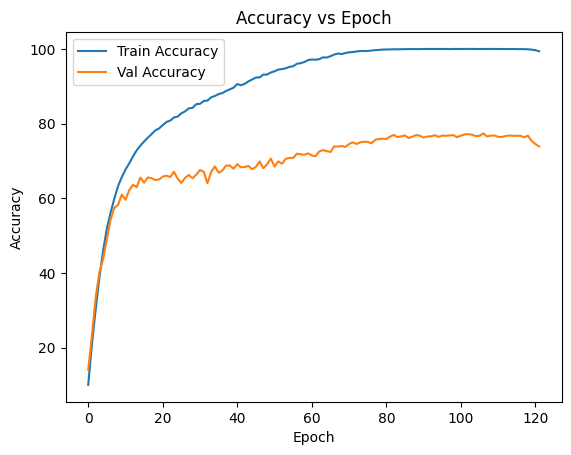

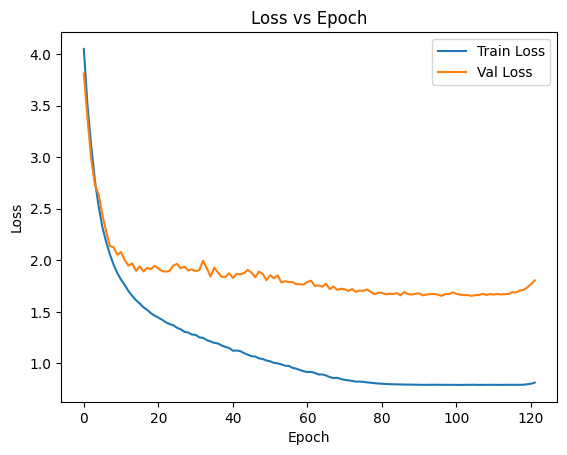

In [12]:
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epoch')
plt.show()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epoch')
plt.show()